# 🧠 Visión Computacional Aplicada a la Industria
## Caso: Detección de Calidad de Limones 🍋

Este notebook muestra cómo aplicar **visión computacional** para un problema real de **control de calidad**.
Aprenderás el flujo completo: desde cargar imágenes, entrenar un modelo preentrenado y analizar los resultados.

💡 *El mismo flujo puede adaptarse a cualquier proceso industrial de inspección visual.*

## 1️⃣ Cargar librerías y explorar el dataset

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
#!pip install gdown
import gdown
import zipfile
from pathlib import Path
import pandas as pd
from tqdm import tqdm

# URL de ejemplo (reemplázala por la tuya)
url = "https://drive.google.com/file/d/1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx/view?usp=sharing"

# Extraer el ID del archivo (la parte después de /d/ y antes de /view)
file_id = url.split("/d/")[1].split("/")[0]
output = "lemon_dataset.zip"

# Descargar el archivo ZIP
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

# Descomprimir
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("dataset")

Downloading...
From (original): https://drive.google.com/uc?id=1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx
From (redirected): https://drive.google.com/uc?id=1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx&confirm=t&uuid=99d6e30b-4cd7-4e1e-b32c-ecfc74b4ee43
To: c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\computer-vision\lemon_dataset.zip
100%|██████████| 244M/244M [00:10<00:00, 23.5MB/s] 


In [4]:
root_path = os.getcwd()

print(root_path)

c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\computer-vision


Found 2528 files belonging to 3 classes.
Using 2023 files for training.
Found 2528 files belonging to 3 classes.
Using 505 files for validation.


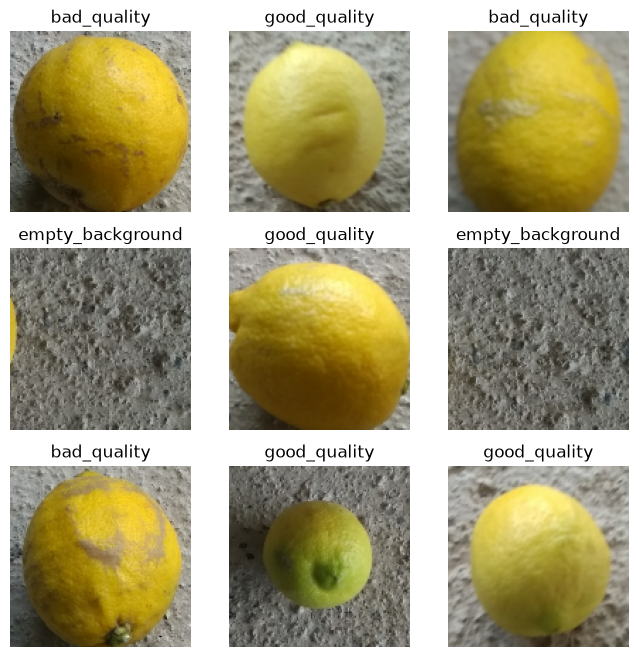

In [7]:
dataset_path = root_path + '/dataset'  # Ruta al dataset (cambiar si es otro caso)

train_ds = image_dataset_from_directory(
    os.path.join(dataset_path, 'lemon_dataset'),
    image_size=(128, 128), validation_split=0.2, subset='training',  batch_size=32, seed=42)
val_ds = image_dataset_from_directory(
    os.path.join(dataset_path, 'lemon_dataset'),
    image_size=(128, 128), validation_split=0.2, subset='validation', batch_size=32, seed=42)

class_names = train_ds.class_names
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()

## 2️⃣ Aumentar los datos (Data Augmentation)
Aumentamos el dataset con transformaciones aleatorias para mejorar la generalización del modelo.

In [8]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## 3️⃣ Crear el modelo con Transfer Learning
Usaremos **MobileNetV2**, un modelo preentrenado en millones de imágenes, y lo adaptaremos a nuestro caso.

In [9]:
# Detectar número de clases
num_classes = len(class_names)
print(f"Número de clases detectadas: {num_classes}")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential, layers

# Cargar base preentrenada (transfer learning)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)
base_model.trainable = False  # Congelamos pesos base

# Armamos el modelo completo
model = Sequential([
    data_augmentation,          # Aumentamos variabilidad
    layers.Rescaling(1./255),   # Normalizamos valores de píxel
    base_model,                 # Modelo preentrenado
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation='softmax')  # Multiclase
])

# Compilamos para problema multiclase
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Número de clases detectadas: 3
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.build((None, 128,128,3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
#from tensorflow.keras.utils import plot_model
#from IPython.display import Image

#plot_model(
#    model,
#    to_file="modelo.png",
#    show_shapes=True,        # Muestra shapes de entrada y salida
#    show_layer_names=True,   # Muestra nombre de capas
#    expand_nested=True,      # Expande MobileNetV2
#    dpi=120
#)

#Image("modelo.png")

In [11]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.8937 - loss: 0.2792 - val_accuracy: 0.9683 - val_loss: 0.1226
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9733 - loss: 0.0913 - val_accuracy: 0.9762 - val_loss: 0.0746
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9862 - loss: 0.0600 - val_accuracy: 0.9762 - val_loss: 0.0642
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9862 - loss: 0.0498 - val_accuracy: 0.9782 - val_loss: 0.0547
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9896 - loss: 0.0392 - val_accuracy: 0.9861 - val_loss: 0.0500


## 5️⃣ Evaluación de resultados

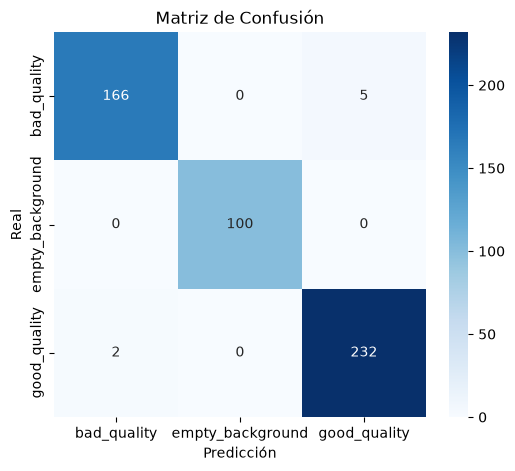

                  precision    recall  f1-score   support

     bad_quality       0.99      0.97      0.98       171
empty_background       1.00      1.00      1.00       100
    good_quality       0.98      0.99      0.99       234

        accuracy                           0.99       505
       macro avg       0.99      0.99      0.99       505
    weighted avg       0.99      0.99      0.99       505


Accuracy real calculado correctamente: 0.9861


In [13]:
# ============================================
# 📌 Evaluación correcta sobre val_ds
#    (sin problemas de prefetch ni desalineación)
# ============================================

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Crear versión del dataset SIN prefetch, sin cache, sin batching complejo
# Crear dataset evaluable (1 imagen por batch)
val_eval = val_ds.unbatch().batch(1)

y_true = []
y_pred = []
images = []
probs = []

for x, y in val_eval:
    p = model.predict(x, verbose=0)[0]
    probs.append(p)
    y_pred.append(np.argmax(p))
    y_true.append(int(y.numpy()[0]))
    images.append(x[0].numpy())

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
probs   = np.array(probs)
images  = np.array(images)


# 3️⃣ Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# 4️⃣ Reporte completo
print(classification_report(y_true, y_pred, target_names=class_names))

# 5️⃣ Accuracy real
accuracy = (y_true == y_pred).mean()
print(f"\nAccuracy real calculado correctamente: {accuracy:.4f}")


In [14]:
model.evaluate(val_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9861 - loss: 0.0500


[0.04998251795768738, 0.986138641834259]

Visualizamos predicciones para ver cómo se comporta el modelo.

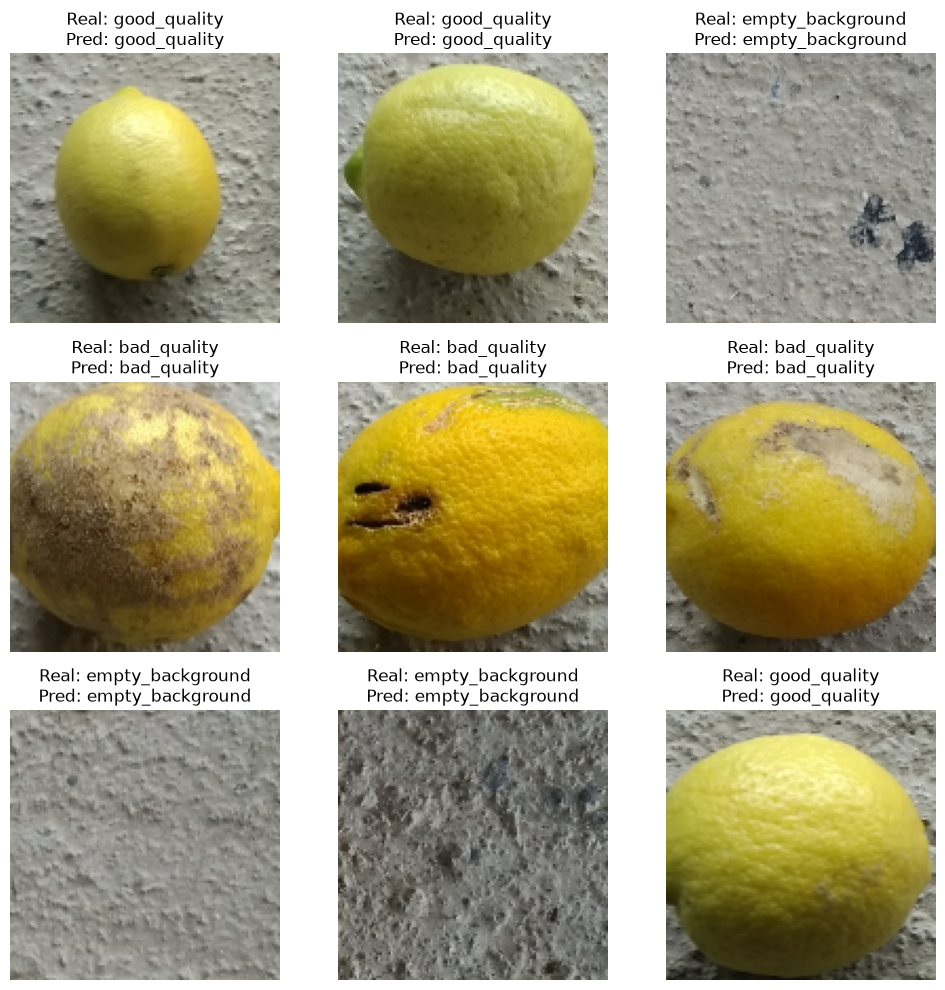

In [15]:
import matplotlib.pyplot as plt

correct_idx = np.where(y_true == y_pred)[0]

N = 9
plt.figure(figsize=(10,10))

for i, idx in enumerate(correct_idx[:N]):
    plt.subplot(3,3,i+1)
    plt.imshow(images[idx].astype("uint8"))
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Visualización de ejemplos mal clasificados

In [16]:
misclassified_idx = np.where(y_true != y_pred)[0]
print("Total de imágenes mal clasificadas:", len(misclassified_idx))

Total de imágenes mal clasificadas: 7


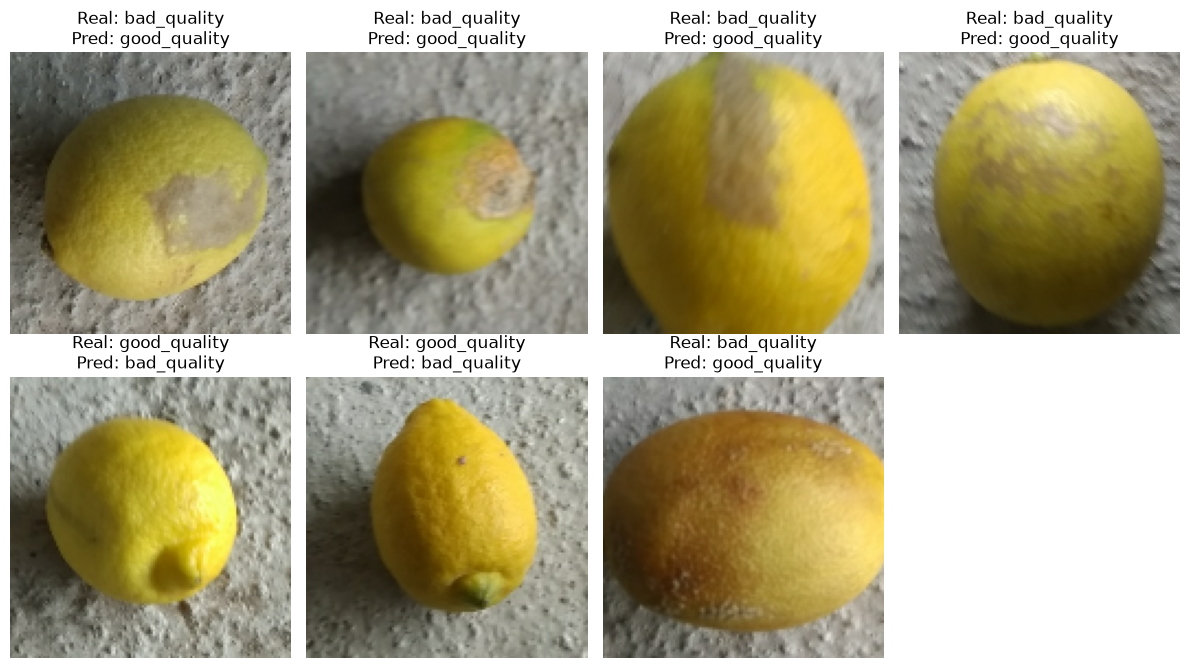

In [17]:
N = 12  # cuántas mostrar
plt.figure(figsize=(12, 10))

for i, idx in enumerate(misclassified_idx[:N]):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[idx].astype("uint8"))
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
class_names

['bad_quality', 'empty_background', 'good_quality']

In [19]:
bad_idx = class_names.index("bad_quality")
malos_mal_clasificados = np.where((y_true == bad_idx) & (y_pred != bad_idx))[0]

print("Bad_quality NO detectados:", len(malos_mal_clasificados))


Bad_quality NO detectados: 5


En producción, nos importa **detectar bien los defectuosos** y reducir riesgos operativos.